# Multi-DiffNet tutorial on simulated data

This notebook demonstrates a complete minimal workflow for **Multi-DiffNet**:

1. simulate one structured multi-omics and multi-tissue dataset,
2. save the simulated data as CSV files,
3. reload the data using the package loader,
4. fit `MultiDiffNet`,
5. inspect the estimated matrices,
6. visualize intra-omics and cross-omics differential networks.


## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_diffnet import MultiDiffNet
from multi_diffnet.data import load_multimodal_supervised, block_slices_from_dims
from multi_diffnet.networks import (
    matrix_to_edge_table,
    plot_low_high_common_networks,
)

from simulation.simulation import simulate_one_scenario

plt.rcParams["figure.dpi"] = 120


## 2. Simulate one structured scenario

In [2]:
data, truth = simulate_one_scenario(
    p=12,
    r=2,
    n0=60,
    n_low=60,
    n_high=60,
    seed=123,
    verbose=True,
)

print("Baseline matrix:", data.data_0.shape)
print("Exposed matrix:", data.data_K.shape)
print("Groups:", data.group_names)
print("Modalities:", data.dims)


=== One simulated MultiDiffNet scenario ===
p per block = 12
total dimension d = 48
latent rank r = 2
n0 = 60, n_low = 60, n_high = 60
lambda_min Theta0_raw = 1.017e-02
baseline shift = 2.898e-01
group global shift = 2.567e+00
condition numbers: 8.760810116737366 4.273885311920806 25.152992863384295
Baseline matrix: (48, 60)
Exposed matrix: (48, 120)
Groups: ['low' 'high']
Modalities: {'omic1_tissue1_A1': 12, 'omic2_tissue1_B1': 12, 'omic1_tissue2_A2': 12, 'omic2_tissue2_B2': 12}


## 3. Save simulated data as CSV files

The simulated data are saved in `simulation/data/` using the same format expected by the package loader:

- one CSV file per modality,
- one metadata file containing the group labels.

In [3]:
data_dir = Path("simulation/data")
data_dir.mkdir(parents=True, exist_ok=True)

# Reconstruct the complete feature x sample matrix
X_full = np.concatenate([data.data_0, data.data_K], axis=1)

sample_names = data.sample_names_baseline + data.sample_names_exposed

group_labels = (
    [data.baseline_group] * len(data.sample_names_baseline)
    + [str(data.group_names[label]) for label in data.labels]
)

metadata = pd.DataFrame({"Group": group_labels}, index=sample_names)
metadata.to_csv(data_dir / "metadata.csv")

idx = block_slices_from_dims(data.dims)

for modality, indices in idx.items():
    X_modality = X_full[indices, :].T  # samples x features
    df = pd.DataFrame(
        X_modality,
        index=sample_names,
        columns=data.feature_names[modality],
    )
    df.to_csv(data_dir / f"{modality}.csv")

print("Saved files:")
for path in sorted(data_dir.glob("*.csv")):
    print(" -", path)


Saved files:
 - simulation\data\metadata.csv
 - simulation\data\omic1_tissue1_A1.csv
 - simulation\data\omic1_tissue2_A2.csv
 - simulation\data\omic2_tissue1_B1.csv
 - simulation\data\omic2_tissue2_B2.csv


## 4. Reload the saved data with the package loader

This step mimics the real-data workflow: the model receives CSV files for each modality and a metadata table.

In [4]:
modalities = {
    modality: data_dir / f"{modality}.csv"
    for modality in data.dims.keys()
}

loaded_data = load_multimodal_supervised(
    modalities=modalities,
    meta_path=data_dir / "metadata.csv",
    group_col="Group",
    baseline_group="baseline",
    do_global_center=False,
    do_group_center=False,
    do_scale=False,
)

print("Reloaded baseline matrix:", loaded_data.data_0.shape)
print("Reloaded exposed matrix:", loaded_data.data_K.shape)
print("Reloaded groups:", loaded_data.group_names)
print("Reloaded modalities:", loaded_data.dims)


Reloaded baseline matrix: (48, 60)
Reloaded exposed matrix: (48, 120)
Reloaded groups: ['high' 'low']
Reloaded modalities: {'omic1_tissue1_A1': 12, 'omic2_tissue1_B1': 12, 'omic1_tissue2_A2': 12, 'omic2_tissue2_B2': 12}


## 5. Fit Multi-DiffNet

In [5]:
model = MultiDiffNet(
    lambda_1=0.05,
    lambda_2={
        "low": 0.07,
        "high": 0.05,
    },
    lambda_3=0.005,
    mu0=1.5,
    rho=1.0,
    eps=1e-2,
    maxiter_baseline=100,
    maxiter_admm=10,
    maxiter_ama=10,
    maxiter_outer=5,
    verbose=True,
)

fit = model.fit(loaded_data)


[JOINT] iter=0 obj=3.086729e+02
[JOINT] iter=1 obj=2.059900e+02 rel_obj=3.327e-01 rel_theta0=2.265e-02 rel_delta=6.763e-02
[JOINT] iter=2 obj=1.300409e+02 rel_obj=3.687e-01 rel_theta0=1.965e-02 rel_delta=3.711e-02
[JOINT] iter=3 obj=7.106827e+01 rel_obj=4.535e-01 rel_theta0=1.764e-02 rel_delta=4.574e-02
[JOINT] iter=4 obj=1.731656e+01 rel_obj=7.563e-01 rel_theta0=1.619e-02 rel_delta=3.208e-02
[JOINT] iter=5 obj=-2.914982e+01 rel_obj=2.683e+00 rel_theta0=1.495e-02 rel_delta=3.206e-02


## 6. Inspect estimated outputs

In [6]:
Theta0 = fit["estimate_0"]["Theta_0"]
S0 = fit["estimate_0"]["S_0"]
L0 = fit["estimate_0"]["L_0"]

ThetaK = fit["estimate_K"]["Theta"]
DeltaK = fit["estimate_K"]["Delta"]

print("Theta0 shape:", Theta0.shape)
print("S0 shape:", S0.shape)
print("L0 shape:", L0.shape)
print("ThetaK shape:", ThetaK.shape)
print("DeltaK shape:", DeltaK.shape)
print("Objective history length:", len(fit["estimate_0"]["joint_objective_history"]))


Theta0 shape: (48, 48)
S0 shape: (48, 48)
L0 shape: (48, 48)
ThetaK shape: (48, 48, 2)
DeltaK shape: (48, 48, 2)
Objective history length: 6


## 7. Plot objective history

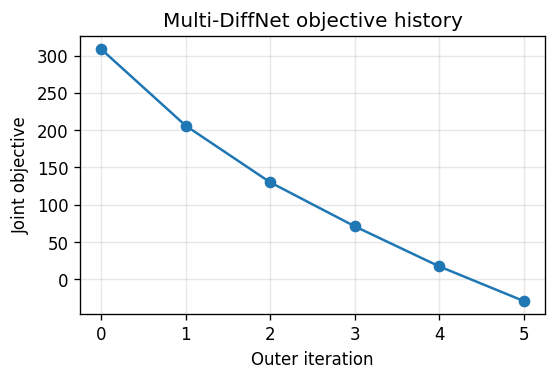

In [7]:
history = fit["estimate_0"]["joint_objective_history"]

plt.figure(figsize=(5, 3))
plt.plot(history, marker="o")
plt.xlabel("Outer iteration")
plt.ylabel("Joint objective")
plt.title("Multi-DiffNet objective history")
plt.grid(alpha=0.3)
plt.show()


## 8. Extract modality blocks

Each differential matrix is block-structured. Diagonal blocks correspond to intra-omics / intra-tissue networks, while off-diagonal blocks capture cross-omics or cross-tissue interactions.

In [8]:
idx = block_slices_from_dims(loaded_data.dims)
modalities = list(loaded_data.dims.keys())

low_id = list(loaded_data.group_names).index("low")
high_id = list(loaded_data.group_names).index("high")

print("low index:", low_id)
print("high index:", high_id)
print("modalities:")
for m in modalities:
    print(" -", m, loaded_data.dims[m])


low index: 1
high index: 0
modalities:
 - omic1_tissue1_A1 12
 - omic2_tissue1_B1 12
 - omic1_tissue2_A2 12
 - omic2_tissue2_B2 12


## 9. Intra-omics network example

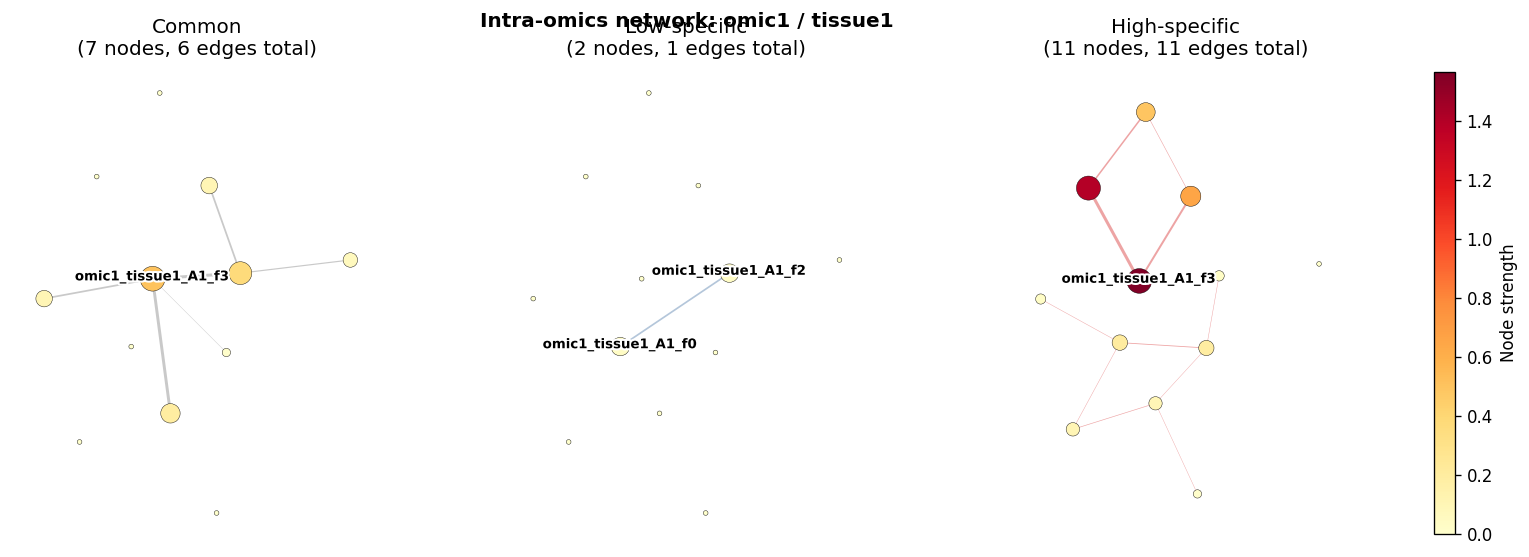

In [9]:
block = "omic1_tissue1_A1"
I = idx[block]

low_block = DeltaK[np.ix_(I, I, [low_id])][:, :, 0]
high_block = DeltaK[np.ix_(I, I, [high_id])][:, :, 0]

fig = plot_low_high_common_networks(
    low_matrix=low_block,
    high_matrix=high_block,
    row_names=loaded_data.feature_names[block],
    col_names=None,
    block_name=block,
    threshold=1e-3,
    title="Intra-omics network: omic1 / tissue1",
    max_labels=8,
    figsize=(16, 5),
)
plt.show()


## 10. Cross-omics network example

In [ ]:
block_row = "omic1_tissue1_A1"
block_col = "omic2_tissue1_B1"

I = idx[block_row]
J = idx[block_col]

low_cross = DeltaK[np.ix_(I, J, [low_id])][:, :, 0]
high_cross = DeltaK[np.ix_(I, J, [high_id])][:, :, 0]

fig = plot_low_high_common_networks(
    low_matrix=low_cross,
    high_matrix=high_cross,
    row_names=loaded_data.feature_names[block_row],
    col_names=loaded_data.feature_names[block_col],
    block_name=f"{block_row}__{block_col}",
    threshold=1e-3,
    title="Cross-omics network: tissue1",
    max_labels=10,
    figsize=(16, 5),
)
plt.show()


## 11. Export edge tables for all blocks

The following cell exports edge tables for every modality block and every exposed group.

In [39]:
network_dir = Path("simulation/output_networks")
network_dir.mkdir(parents=True, exist_ok=True)

threshold = 1e-3

for k, group_name in enumerate(loaded_data.group_names):
    group_dir = network_dir / str(group_name)
    group_dir.mkdir(parents=True, exist_ok=True)

    Delta_k = DeltaK[:, :, k]

    for i, row_block in enumerate(modalities):
        for j, col_block in enumerate(modalities):
            if j < i:
                continue

            I = idx[row_block]
            J = idx[col_block]
            block_matrix = Delta_k[np.ix_(I, J)]

            if row_block == col_block:
                edges = matrix_to_edge_table(
                    block_matrix,
                    feature_names=loaded_data.feature_names[row_block],
                    threshold=threshold,
                )
                block_type = "intra"
            else:
                rows = loaded_data.feature_names[row_block]
                cols = loaded_data.feature_names[col_block]
                records = []
                for a, source in enumerate(rows):
                    for b, target in enumerate(cols):
                        w = float(block_matrix[a, b])
                        if abs(w) > threshold:
                            records.append(
                                {
                                    "source": source,
                                    "target": target,
                                    "weight": w,
                                    "abs_weight": abs(w),
                                }
                            )
                edges = pd.DataFrame(records)
                block_type = "cross"

            out_name = f"{block_type}_{row_block}__{col_block}_edges.csv"
            edges.to_csv(group_dir / out_name, index=False)

            print(
                f"group={group_name} | block={row_block}__{col_block} | "
                f"type={block_type} | edges={len(edges)}"
            )


group=high | block=omic1_tissue1_A1__omic1_tissue1_A1 | type=intra | edges=17
group=high | block=omic1_tissue1_A1__omic2_tissue1_B1 | type=cross | edges=41
group=high | block=omic1_tissue1_A1__omic1_tissue2_A2 | type=cross | edges=29
group=high | block=omic1_tissue1_A1__omic2_tissue2_B2 | type=cross | edges=39
group=high | block=omic2_tissue1_B1__omic2_tissue1_B1 | type=intra | edges=17
group=high | block=omic2_tissue1_B1__omic1_tissue2_A2 | type=cross | edges=41
group=high | block=omic2_tissue1_B1__omic2_tissue2_B2 | type=cross | edges=31
group=high | block=omic1_tissue2_A2__omic1_tissue2_A2 | type=intra | edges=14
group=high | block=omic1_tissue2_A2__omic2_tissue2_B2 | type=cross | edges=27
group=high | block=omic2_tissue2_B2__omic2_tissue2_B2 | type=intra | edges=22
group=low | block=omic1_tissue1_A1__omic1_tissue1_A1 | type=intra | edges=7
group=low | block=omic1_tissue1_A1__omic2_tissue1_B1 | type=cross | edges=18
group=low | block=omic1_tissue1_A1__omic1_tissue2_A2 | type=cross |

## 12. Save selected figures

This cell shows how to save figures generated from selected blocks. You can adapt the block names to export additional panels.

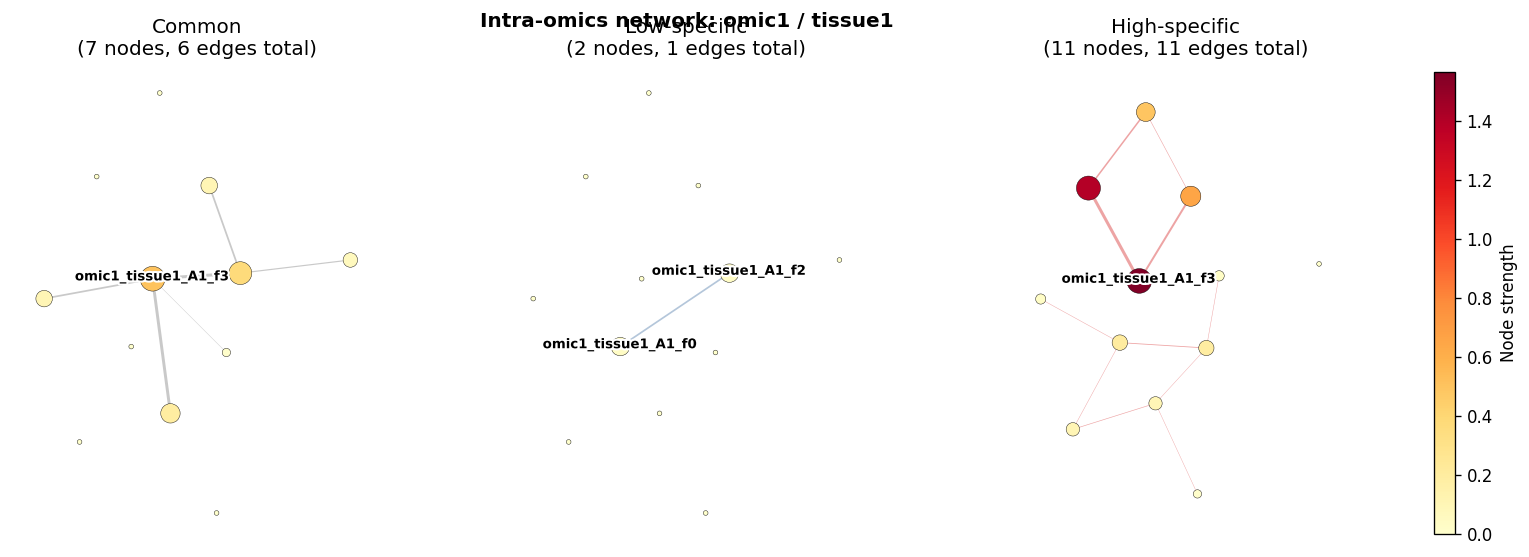

In [40]:
fig_dir = Path("simulation/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Example: save intra-omics figure
block = "omic1_tissue1_A1"
I = idx[block]
low_block = DeltaK[np.ix_(I, I, [low_id])][:, :, 0]
high_block = DeltaK[np.ix_(I, I, [high_id])][:, :, 0]

fig = plot_low_high_common_networks(
    low_matrix=low_block,
    high_matrix=high_block,
    row_names=loaded_data.feature_names[block],
    block_name=block,
    threshold=1e-3,
    title="Intra-omics network: omic1 / tissue1",
    max_labels=8,
    figsize=(16, 5),
)

fig.savefig(fig_dir / "intra_omics_omic1_tissue1.png", bbox_inches="tight")
fig.savefig(fig_dir / "intra_omics_omic1_tissue1.pdf", bbox_inches="tight")
plt.show()


## 13. Save fitted matrices

The package can also save all baseline and group-specific estimated blocks.

In [41]:
results_dir = Path("simulation/results_multidiffnet")
model.save_results(results_dir, loaded_data)

print("Saved results")


Saved results
